# Urban VLM — Joint Classification + Regression Training (Safety Attribute)

**Extension of:** Simplified UrbanVLM Pipeline on Place Pulse 2.0

**What's new in this notebook:**
- Implements the **combined loss function** from the UrbanVLM paper
- Two output heads trained **simultaneously**: classification (0/1) + regression (0–10)
- Total loss = λ_class × CrossEntropyLoss + λ_reg × MSELoss
- Safety attribute only
- Both image-only (512-dim) and image+caption (1024-dim) versions trained

**Based on:** UrbanVLM (IJCNN 2025) — simplified version without contrastive learning

**Hardware:** A100 80GB (enable High RAM slider)

---

## Section 1: Install and Imports

In [ ]:
!pip install -q transformers>=4.40.0 accelerate Pillow tqdm pandas scikit-learn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import pandas as pd
import numpy as np
import os
import random
from PIL import Image as PILImage
from tqdm import tqdm
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import mean_absolute_error, r2_score
from torch.utils.data import TensorDataset, DataLoader

print("GPU available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("VRAM (GB):", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

GPU available: True
GPU name: NVIDIA A100-SXM4-80GB
VRAM (GB): 85.1


## Section 2: Mount Drive and Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
if not os.path.exists("/content/votes.tsv"):
    !unzip -q "/content/drive/MyDrive/place-pulse-2.0 (2).zip" -d /content/
    print("Unzip complete.")
else:
    print("Already unzipped, skipping.")

Unzip complete.


In [ ]:
df_votes   = pd.read_csv("/content/votes.tsv", sep="\t")
df_studies = pd.read_csv("/content/studies.tsv", sep="\t")
image_dir  = "/content/images"

print("Votes shape:  ", df_votes.shape)
print("Studies shape:", df_studies.shape)
print("Total images: ", len(os.listdir(image_dir)))

Votes shape:   (1555561, 7)
Studies shape: (6, 6)
Total images:  110988


## Section 3: Configuration

Fixed to **safer** attribute only for this notebook.

In [ ]:
# ============================================================
# Configuration — SAFER attribute only
# N_SAMPLES: number of images to use
#   500  = ~25 mins caption gen (recommended)
#   1000 = ~50 mins caption gen (stronger results)
# LAMBDA_CLASS: weight for classification loss
# LAMBDA_REG:   weight for regression loss
# ============================================================
ATTRIBUTE_NAME = "safer"
N_SAMPLES      = 500
EPOCHS         = 20
LR             = 1e-3
LAMBDA_CLASS   = 1.0   # weight for CrossEntropy loss
LAMBDA_REG     = 1.0   # weight for MSE loss

ATTRIBUTE_MAP = {
    "beautiful":       "5217c351ad93a7d3e7b07a64",
    "safer":           "50a68a51fdc9f05596000002",
    "livelier":        "50f62c41a84ea7c5fdd2e454",
    "more boring":     "50f62c68a84ea7c5fdd2e456",
    "wealthier":       "50f62cb7a84ea7c5fdd2e458",
    "more depressing": "50f62ccfa84ea7c5fdd2e459",
}

STUDY_ID = ATTRIBUTE_MAP[ATTRIBUTE_NAME]
print(f"Attribute:     {ATTRIBUTE_NAME}")
print(f"Study ID:      {STUDY_ID}")
print(f"N samples:     {N_SAMPLES}")
print(f"Lambda class:  {LAMBDA_CLASS}")
print(f"Lambda reg:    {LAMBDA_REG}")

Attribute:     safer
Study ID:      50a68a51fdc9f05596000002
N samples:     500
Lambda class:  1.0
Lambda reg:    1.0


## Section 4: Build Image Map

In [ ]:
df_votes = df_votes[df_votes["choice"].isin(["left", "right"])].copy()
print("Valid votes:", len(df_votes))

image_map = {}
for file in os.listdir(image_dir):
    if file.lower().endswith(".jpg"):
        parts = file.split("_")
        if len(parts) >= 3:
            image_id = parts[2]
            image_map[image_id] = os.path.join(image_dir, file)

print("Total images mapped:", len(image_map))

Valid votes: 1350546
Total images mapped: 110988


## Section 5: Q-Score Computation

Computes continuous Q-scores (0–10) from raw pairwise votes.
Then derives binary labels using the **median threshold** (same as paper):
- score >= median → label = 1 (safe)
- score <  median → label = 0 (unsafe)

In [ ]:
attr_votes = df_votes[df_votes["study_id"] == STUDY_ID].copy()

image_wins_raw   = defaultdict(int)
image_losses_raw = defaultdict(int)

for _, row in attr_votes.iterrows():
    left_id  = row["left"]
    right_id = row["right"]
    if row["choice"] == "left":
        image_wins_raw[left_id]    += 1
        image_losses_raw[right_id] += 1
    else:
        image_wins_raw[right_id]   += 1
        image_losses_raw[left_id]  += 1

MIN_COMPARISONS = 10
image_scores_agg = {}
for img_id in image_wins_raw:
    if img_id not in image_map:
        continue
    wins   = image_wins_raw[img_id]
    losses = image_losses_raw.get(img_id, 0)
    total  = wins + losses
    if total < MIN_COMPARISONS:
        continue
    image_scores_agg[img_id] = round((wins / total) * 10, 3)

scores_list = list(image_scores_agg.values())
median_score = np.median(scores_list)

print(f"Images with >= {MIN_COMPARISONS} comparisons: {len(image_scores_agg)}")
print(f"Score range: {min(scores_list):.3f} - {max(scores_list):.3f}")
print(f"Mean:        {np.mean(scores_list):.3f}")
print(f"Median (classification threshold): {median_score:.3f}")

Images with >= 10 comparisons: 43447
Score range: 0.204 - 10.000
Mean:        5.044
Median (classification threshold): 5.000


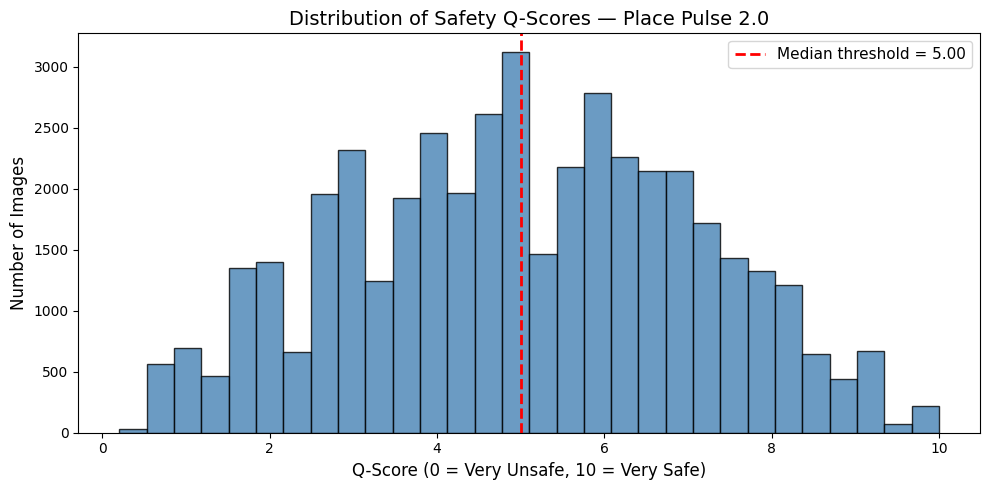

Images labeled Safe (1):   23804
Images labeled Unsafe (0): 19643


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(scores_list, bins=30, color='steelblue', edgecolor='black', alpha=0.8)
plt.axvline(median_score, color='red', linestyle='--', linewidth=2,
            label=f'Median threshold = {median_score:.2f}')
plt.xlabel('Q-Score (0 = Very Unsafe, 10 = Very Safe)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Distribution of Safety Q-Scores — Place Pulse 2.0', fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

print(f"Images labeled Safe (1):   {sum(1 for s in scores_list if s >= median_score)}")
print(f"Images labeled Unsafe (0): {sum(1 for s in scores_list if s < median_score)}")

## Section 6: Load LLaVA-1.5 for Caption Generation

In [ ]:
from transformers import LlavaProcessor, LlavaForConditionalGeneration

model_id  = "llava-hf/llava-1.5-7b-hf"
processor = LlavaProcessor.from_pretrained(model_id)

llava_model = LlavaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.float16,
    low_cpu_mem_usage=True
).to("cuda")

print("LLaVA model loaded.")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/701 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/674 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/505 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/686 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/141 [00:00<?, ?B/s]

LLaVA model loaded.


## Section 7: Caption Generation

Attribute-specific prompt for **safer**, following paper's Appendix D structure exactly.

In [ ]:
SAFER_PROMPT = (
    "USER: <image>\n"
    "Imagine you are an observer analyzing a street view image. "
    "Based on the street view image provided, please describe the "
    "factors that contribute to making this street view image feel safe. "
    "Consider elements such as the visual appearance, environment, "
    "colors, structures, infrastructure, well-maintained level, "
    "daylight, lighting quality, presence of people, signs of "
    "disorder or neglect, and any human or social factors.\n"
    "ASSISTANT:"
)

caption_cache = {}

def generate_caption(img_id):
    if img_id in caption_cache:
        return caption_cache[img_id]
    try:
        image  = PILImage.open(image_map[img_id]).convert("RGB")
        inputs = processor(
            text=SAFER_PROMPT,
            images=image,
            return_tensors="pt"
        ).to("cuda", torch.float16)

        with torch.no_grad():
            output = llava_model.generate(
                **inputs,
                max_new_tokens=100,
                do_sample=False
            )
        decoded = processor.decode(output[0], skip_special_tokens=True)
        caption = decoded.split("ASSISTANT:")[-1].strip()
        caption_cache[img_id] = caption
        return caption
    except Exception as e:
        return None

print("Caption generator ready.")

Caption generator ready.


## Section 8: Load CLIP

In [ ]:
from transformers import CLIPModel, CLIPProcessor

clip_model     = CLIPModel.from_pretrained("openai/clip-vit-base-patch32").to("cuda")
clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

print("CLIP model loaded.")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

CLIP model loaded.


## Section 9: Dual-Modality Encoding

For each image:
- CLIP image encoder → 512-dim vector
- CLIP text encoder on LLaVA caption → 512-dim vector
- Concatenated → 1024-dim vector

Both image-only (512) and image+caption (1024) stored for comparison.

In [ ]:
random.seed(42)
subset = random.sample(
    list(image_scores_agg.items()),
    min(N_SAMPLES, len(image_scores_agg))
)

X_image_only    = []   # 512-dim
X_image_caption = []   # 1024-dim
y_reg           = []   # continuous Q-score 0-10
y_cls           = []   # binary label 0 or 1

for img_id, score in tqdm(subset, desc="Encoding [safer]"):
    try:
        image = PILImage.open(image_map[img_id]).convert("RGB")

        # CLIP image embedding
        inp = clip_processor(images=image, return_tensors="pt").to("cuda")
        with torch.no_grad():
            vision_out = clip_model.vision_model(**inp)
            img_emb    = clip_model.visual_projection(
                vision_out.pooler_output
            )[0].cpu().numpy()  # 512-dim

        # LLaVA caption
        caption = generate_caption(img_id)
        if not caption:
            continue

        # CLIP text embedding
        txt_inp = clip_processor(
            text=[caption],
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=77
        ).to("cuda")
        with torch.no_grad():
            text_out = clip_model.text_model(**txt_inp)
            txt_emb  = clip_model.text_projection(
                text_out.pooler_output
            )[0].cpu().numpy()  # 512-dim

        # Binary label using median threshold
        label = 1 if score >= median_score else 0

        X_image_only.append(img_emb)
        X_image_caption.append(np.concatenate([img_emb, txt_emb]))
        y_reg.append(score)
        y_cls.append(label)

    except:
        continue

X_img = np.array(X_image_only)
X_cap = np.array(X_image_caption)
y_reg = np.array(y_reg)
y_cls = np.array(y_cls)

print(f"\nEncoded: {len(y_reg)} images")
print(f"Image-only shape:    {X_img.shape}")
print(f"Image+caption shape: {X_cap.shape}")
print(f"Class distribution — Safe (1): {y_cls.sum()} | Unsafe (0): {(y_cls==0).sum()}")

Encoding [safer]: 100%|██████████| 500/500 [31:46<00:00,  3.81s/it]


Encoded: 500 images
Image-only shape:    (500, 512)
Image+caption shape: (500, 1024)
Class distribution — Safe (1): 280 | Unsafe (0): 220


In [ ]:
# Print sample captions generated by LLaVA
print("Sample captions generated by LLaVA for SAFER attribute:\n")
for i, (img_id, caption) in enumerate(list(caption_cache.items())[:5]):
    print(f"Image {i+1}: {img_id}")
    print(f"Caption: {caption}")
    print("-" * 60)

Sample captions generated by LLaVA for SAFER attribute:

Image 1: 514229a7fdc9f04926008882
Caption: The street view image appears to be safe due to several factors. Firstly, the street is clean and well-maintained, which indicates that the city takes care of its infrastructure. Secondly, the presence of multiple cars and people walking along the sidewalk suggests that the area is active and populated, which can contribute to a sense of safety. Additionally, the image is captured during daylight hours, which provides better visibility and allows for easier identification of potential hazards. The buildings
------------------------------------------------------------
Image 2: 50f5eaaefdc9f065f0007c23
Caption: The street view image appears to be safe due to several factors. Firstly, the street is clean and well-maintained, which indicates that the area is well-cared for. Secondly, the presence of a fence and a gate suggests that the property is secure and potentially private. Thirdly, the

## Section 10: Train/Test Split

In [ ]:
# Split image-only features
X_img_tr, X_img_te, y_reg_tr, y_reg_te, y_cls_tr, y_cls_te = train_test_split(
    X_img, y_reg, y_cls,
    test_size=0.25, random_state=42
)

# Split image+caption features (same indices via random_state=42)
X_cap_tr, X_cap_te, _, _, _, _ = train_test_split(
    X_cap, y_reg, y_cls,
    test_size=0.25, random_state=42
)

print(f"Train: {len(y_reg_tr)} | Test: {len(y_reg_te)}")
print(f"Test class distribution — Safe: {y_cls_te.sum()} | Unsafe: {(y_cls_te==0).sum()}")

Train: 375 | Test: 125
Test class distribution — Safe: 69 | Unsafe: 56


## Section 11: Joint Model Architecture

Two-head neural network:
- **Shared backbone**: Linear(input_dim → 256) + ReLU + Dropout
- **Classification head**: Linear(256 → 2) → outputs logits for CrossEntropyLoss
- **Regression head**: Linear(256 → 1) → outputs continuous score for MSELoss

**Combined loss** (from UrbanVLM paper):

L_total = λ_class × CrossEntropyLoss + λ_reg × MSELoss

In [ ]:
class JointUrbanVLMHead(nn.Module):
    """
    Joint classification + regression head.
    Matches the UrbanVLM paper's Stage 4 design:
    - Binary classification head (safe=1 / unsafe=0)
    - Regression head (continuous Q-score 0-10)
    Both trained simultaneously with combined loss.
    """
    def __init__(self, input_dim):
        super().__init__()
        # Shared backbone
        self.backbone = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        # Classification head — outputs 2 logits (unsafe=0, safe=1)
        self.cls_head = nn.Linear(256, 2)
        # Regression head — outputs single continuous score
        self.reg_head = nn.Linear(256, 1)

    def forward(self, x):
        shared   = self.backbone(x)
        cls_logits = self.cls_head(shared)       # (batch, 2)
        reg_score  = self.reg_head(shared).squeeze(-1)  # (batch,)
        return cls_logits, reg_score

print("JointUrbanVLMHead defined.")
print("Architecture:")
print("  Input → Linear(input_dim, 256) → ReLU → Dropout(0.3)")
print("  → [Classification head: Linear(256, 2)]  → CrossEntropyLoss")
print("  → [Regression head:     Linear(256, 1)]  → MSELoss")
print("  Total loss = λ_class × CE + λ_reg × MSE")

JointUrbanVLMHead defined.
Architecture:
  Input → Linear(input_dim, 256) → ReLU → Dropout(0.3)
  → [Classification head: Linear(256, 2)]  → CrossEntropyLoss
  → [Regression head:     Linear(256, 1)]  → MSELoss
  Total loss = λ_class × CE + λ_reg × MSE


## Section 12: Training Function

Trains the joint model and evaluates on test set each epoch.
Best model checkpoint saved based on lowest validation MAE.

In [ ]:
def train_joint_model(X_tr, X_te, input_dim, label=""):
    """
    Train joint classification + regression model.
    Combined loss = LAMBDA_CLASS * CrossEntropy + LAMBDA_REG * MSE
    """
    # Convert to tensors
    X_tr_t  = torch.tensor(X_tr, dtype=torch.float32)
    y_cls_t = torch.tensor(y_cls_tr, dtype=torch.long)
    y_reg_t = torch.tensor(y_reg_tr, dtype=torch.float32)
    X_te_t  = torch.tensor(X_te, dtype=torch.float32)

    train_ds = TensorDataset(X_tr_t, y_cls_t, y_reg_t)
    train_dl = DataLoader(train_ds, batch_size=32, shuffle=True)

    model     = JointUrbanVLMHead(input_dim=input_dim).to("cuda")
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.01)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

    ce_loss  = nn.CrossEntropyLoss()
    mse_loss = nn.MSELoss()

    best_mae      = float("inf")
    best_cls_pred = None
    best_reg_pred = None
    loss_history  = []
    acc_history   = []

    print(f"\nTraining {label} | input_dim={input_dim}")
    print(f"Loss = {LAMBDA_CLASS} × CrossEntropy + {LAMBDA_REG} × MSE")
    print("-" * 55)

    for epoch in range(EPOCHS):
        model.train()
        epoch_loss = 0.0

        for X_batch, y_cls_batch, y_reg_batch in train_dl:
            X_batch     = X_batch.to("cuda")
            y_cls_batch = y_cls_batch.to("cuda")
            y_reg_batch = y_reg_batch.to("cuda")

            cls_logits, reg_score = model(X_batch)

            # Classification loss (CrossEntropy)
            loss_cls = ce_loss(cls_logits, y_cls_batch)

            # Regression loss (MSE)
            loss_reg = mse_loss(reg_score, y_reg_batch)

            # Combined loss — from UrbanVLM paper
            loss = LAMBDA_CLASS * loss_cls + LAMBDA_REG * loss_reg

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()

        # Evaluate on test set
        model.eval()
        with torch.no_grad():
            cls_logits_te, reg_pred_te = model(X_te_t.to("cuda"))
            cls_pred_te = torch.argmax(cls_logits_te, dim=1).cpu().numpy()
            reg_pred_te = reg_pred_te.cpu().numpy()

        mae = mean_absolute_error(y_reg_te, reg_pred_te)

        # Append after evaluation so cls_pred_te exists
        loss_history.append(epoch_loss / len(train_dl))
        acc_history.append(accuracy_score(y_cls_te, cls_pred_te))

        if mae < best_mae:
            best_mae      = mae
            best_cls_pred = cls_pred_te.copy()
            best_reg_pred = reg_pred_te.copy()

        if (epoch + 1) % 5 == 0:
            acc = accuracy_score(y_cls_te, cls_pred_te)
            print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
                  f"Loss: {epoch_loss/len(train_dl):.4f} | "
                  f"MAE: {mae:.3f} | Acc: {acc:.3f}")

    return best_cls_pred, best_reg_pred, loss_history, acc_history

print("Training function defined.")

Training function defined.


## Section 13: Run Training — Image Only (512-dim)

Baseline: only CLIP image embeddings, no caption.

In [ ]:
cls_pred_img, reg_pred_img, loss_img, acc_img = train_joint_model(
    X_tr=X_img_tr,
    X_te=X_img_te,
    input_dim=512,
    label="IMAGE ONLY (512-dim)"
)


Training IMAGE ONLY (512-dim) | input_dim=512
Loss = 1.0 × CrossEntropy + 1.0 × MSE
-------------------------------------------------------
Epoch 05/20 | Loss: 3.5656 | MAE: 1.420 | Acc: 0.720
Epoch 10/20 | Loss: 2.9703 | MAE: 1.289 | Acc: 0.760
Epoch 15/20 | Loss: 2.7778 | MAE: 1.272 | Acc: 0.792
Epoch 20/20 | Loss: 2.8492 | MAE: 1.263 | Acc: 0.784


## Section 14: Run Training — Image + Caption (1024-dim)

Full dual-modality: CLIP image (512) + CLIP-encoded LLaVA caption (512) = 1024-dim.

In [ ]:
cls_pred_cap, reg_pred_cap, loss_cap, acc_cap = train_joint_model(
    X_tr=X_cap_tr,
    X_te=X_cap_te,
    input_dim=1024,
    label="IMAGE + CAPTION (1024-dim)"
)


Training IMAGE + CAPTION (1024-dim) | input_dim=1024
Loss = 1.0 × CrossEntropy + 1.0 × MSE
-------------------------------------------------------
Epoch 05/20 | Loss: 3.6713 | MAE: 1.397 | Acc: 0.768
Epoch 10/20 | Loss: 2.9690 | MAE: 1.291 | Acc: 0.808
Epoch 15/20 | Loss: 2.6706 | MAE: 1.265 | Acc: 0.792
Epoch 20/20 | Loss: 2.6721 | MAE: 1.260 | Acc: 0.792


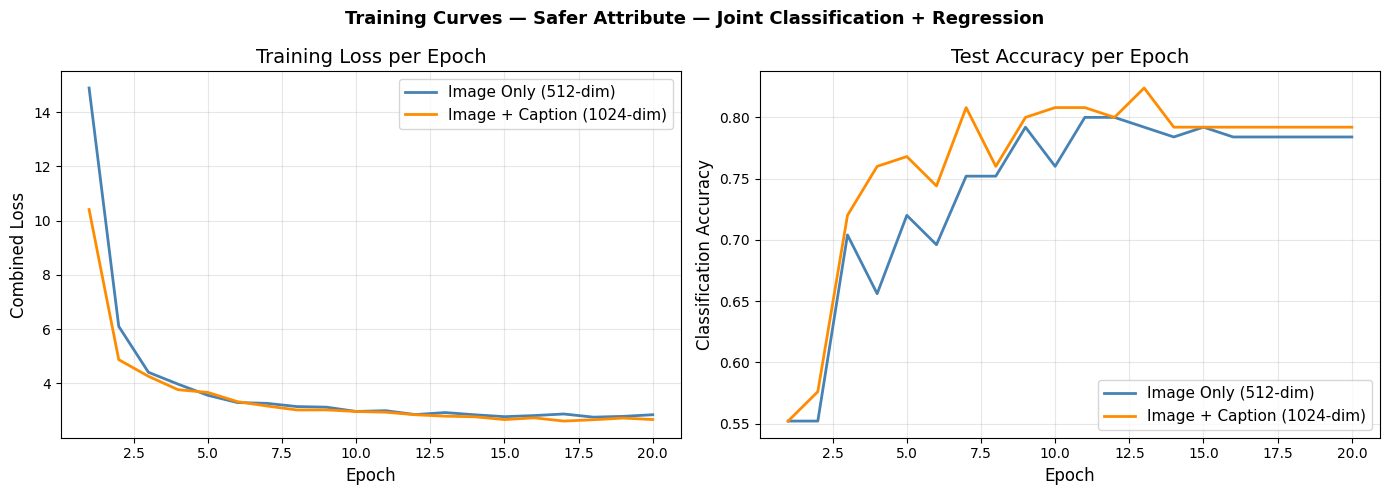

In [ ]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve
axes[0].plot(epochs_range, loss_img, color='steelblue', linewidth=2,
             label='Image Only (512-dim)')
axes[0].plot(epochs_range, loss_cap, color='darkorange', linewidth=2,
             label='Image + Caption (1024-dim)')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Combined Loss', fontsize=12)
axes[0].set_title('Training Loss per Epoch', fontsize=14)
axes[0].legend(fontsize=11)
axes[0].grid(alpha=0.3)

# Accuracy curve
axes[1].plot(epochs_range, acc_img, color='steelblue', linewidth=2,
             label='Image Only (512-dim)')
axes[1].plot(epochs_range, acc_cap, color='darkorange', linewidth=2,
             label='Image + Caption (1024-dim)')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Classification Accuracy', fontsize=12)
axes[1].set_title('Test Accuracy per Epoch', fontsize=14)
axes[1].legend(fontsize=11)
axes[1].grid(alpha=0.3)

plt.suptitle('Training Curves — Safer Attribute — Joint Classification + Regression',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 15: Final Results

Comprehensive evaluation: Classification (Accuracy, Precision, Recall, F1) + Regression (MAE, R², RMSE)

In [ ]:
def evaluate(cls_pred, reg_pred, label):
    acc  = accuracy_score(y_cls_te, cls_pred)
    prec = precision_score(y_cls_te, cls_pred, zero_division=0)
    rec  = recall_score(y_cls_te, cls_pred, zero_division=0)
    f1   = f1_score(y_cls_te, cls_pred, zero_division=0)
    mae  = mean_absolute_error(y_reg_te, reg_pred)
    r2   = r2_score(y_reg_te, reg_pred)
    rmse = np.sqrt(np.mean((reg_pred - y_reg_te) ** 2))
    return {
        "label":     label,
        "acc":       round(acc,  3),
        "precision": round(prec, 3),
        "recall":    round(rec,  3),
        "f1":        round(f1,   3),
        "mae":       round(mae,  3),
        "r2":        round(r2,   3),
        "rmse":      round(rmse, 3),
    }

res_img = evaluate(cls_pred_img, reg_pred_img, "Image only (512-dim)")
res_cap = evaluate(cls_pred_cap, reg_pred_cap, "Image + Caption (1024-dim)")

print("=" * 65)
print("FINAL RESULTS — SAFER ATTRIBUTE — JOINT CLASSIFICATION + REGRESSION")
print("Combined Loss = λ_class × CrossEntropy + λ_reg × MSE")
print(f"λ_class = {LAMBDA_CLASS} | λ_reg = {LAMBDA_REG}")
print("=" * 65)
print(f"{'Metric':<12} {'Image Only':>15} {'Image+Caption':>15} {'Boost':>10}")
print("-" * 65)
for key, label in [("acc","Accuracy"),("precision","Precision"),("recall","Recall"),("f1","F1 Score")]:
    boost = res_cap[key] - res_img[key]
    print(f"{label:<12} {res_img[key]:>15.3f} {res_cap[key]:>15.3f} {boost:>+10.3f}")
print("-" * 65)
for key, label in [("mae","MAE"),("r2","R²"),("rmse","RMSE")]:
    boost = res_cap[key] - res_img[key]
    print(f"{label:<12} {res_img[key]:>15.3f} {res_cap[key]:>15.3f} {boost:>+10.3f}")
print("=" * 65)

# Compare against previous single-task results
print("\nPrevious single-task results (regression only, from last notebook):")
print(f"  Image only acc:    0.700  | Image+Caption acc: 0.816")
print("\nNote: Joint training directly optimizes for classification")
print("instead of using a post-hoc median threshold — results may differ.")

FINAL RESULTS — SAFER ATTRIBUTE — JOINT CLASSIFICATION + REGRESSION
Combined Loss = λ_class × CrossEntropy + λ_reg × MSE
λ_class = 1.0 | λ_reg = 1.0
Metric            Image Only   Image+Caption      Boost
-----------------------------------------------------------------
Accuracy               0.784           0.792     +0.008
Precision              0.744           0.747     +0.003
Recall                 0.928           0.942     +0.014
F1 Score               0.826           0.833     +0.007
-----------------------------------------------------------------
MAE                    1.263           1.260     -0.003
R²                     0.493           0.496     +0.003
RMSE                   1.572           1.568     -0.004

Previous single-task results (regression only, from last notebook):
  Image only acc:    0.700  | Image+Caption acc: 0.816

Note: Joint training directly optimizes for classification
instead of using a post-hoc median threshold — results may differ.


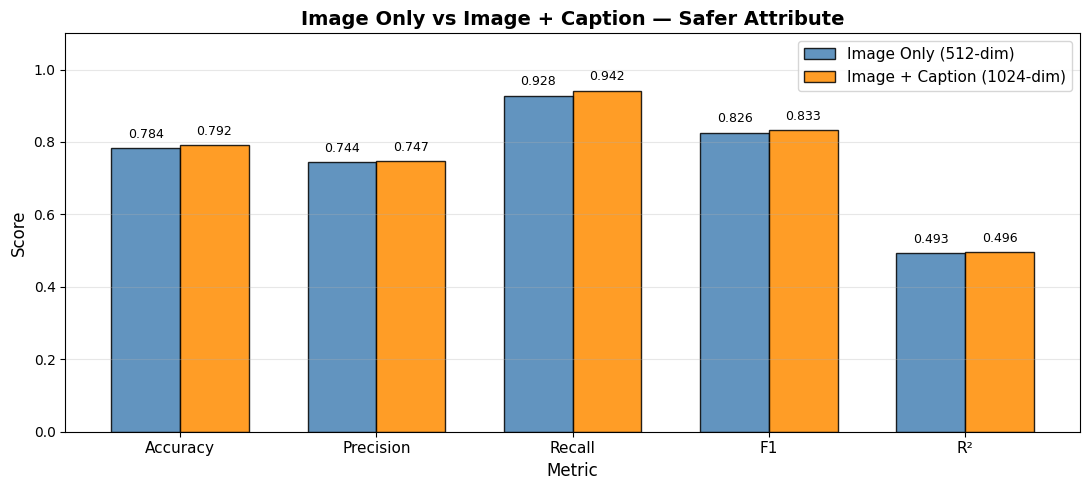

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics      = ["Accuracy", "Precision", "Recall", "F1", "R²"]
img_values   = [res_img["acc"], res_img["precision"], res_img["recall"], res_img["f1"], res_img["r2"]]
cap_values   = [res_cap["acc"], res_cap["precision"], res_cap["recall"], res_cap["f1"], res_cap["r2"]]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
bars1 = ax.bar(x - width/2, img_values, width, label="Image Only (512-dim)",
               color="steelblue", edgecolor="black", alpha=0.85)
bars2 = ax.bar(x + width/2, cap_values, width, label="Image + Caption (1024-dim)",
               color="darkorange", edgecolor="black", alpha=0.85)

ax.set_xlabel("Metric", fontsize=12)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Image Only vs Image + Caption — Safer Attribute", fontsize=14, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.legend(fontsize=11)
ax.grid(axis="y", alpha=0.3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

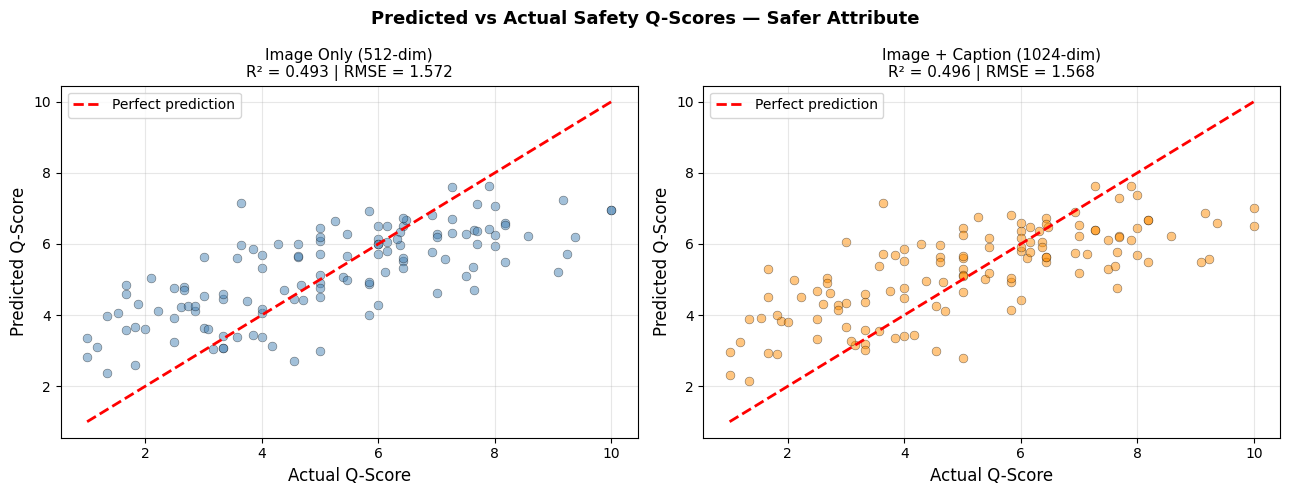

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, reg_pred, label, color in zip(
    axes,
    [reg_pred_img, reg_pred_cap],
    ["Image Only (512-dim)", "Image + Caption (1024-dim)"],
    ["steelblue", "darkorange"]
):
    ax.scatter(y_reg_te, reg_pred, alpha=0.5, color=color, edgecolors="black",
               linewidths=0.4, s=40)

    # Perfect prediction line
    min_val = min(y_reg_te.min(), reg_pred.min())
    max_val = max(y_reg_te.max(), reg_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2,
            label="Perfect prediction")

    ax.set_xlabel("Actual Q-Score", fontsize=12)
    ax.set_ylabel("Predicted Q-Score", fontsize=12)
    ax.set_title(f"{label}\nR² = {r2_score(y_reg_te, reg_pred):.3f} | "
                 f"RMSE = {np.sqrt(np.mean((reg_pred - y_reg_te)**2)):.3f}", fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)

plt.suptitle("Predicted vs Actual Safety Q-Scores — Safer Attribute",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

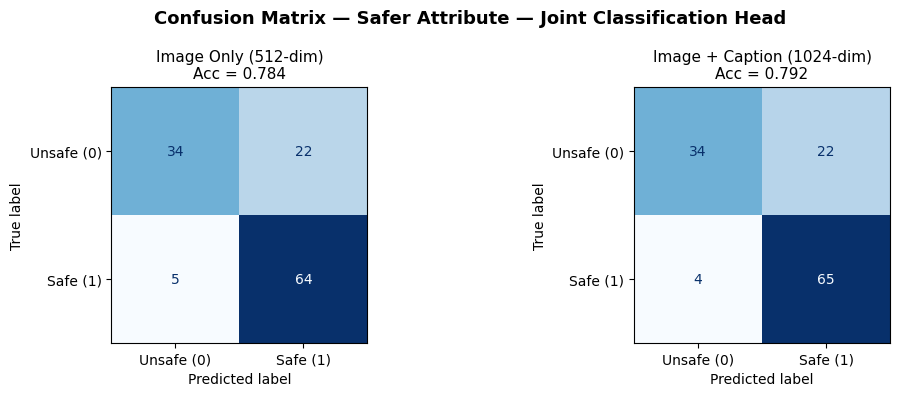

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, cls_pred, label in zip(
    axes,
    [cls_pred_img, cls_pred_cap],
    ["Image Only (512-dim)", "Image + Caption (1024-dim)"]
):
    cm = confusion_matrix(y_cls_te, cls_pred)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Unsafe (0)", "Safe (1)"]
    )
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{label}\nAcc = {accuracy_score(y_cls_te, cls_pred):.3f}", fontsize=11)

plt.suptitle("Confusion Matrix — Safer Attribute — Joint Classification Head",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Section 16: Summary Table

In [ ]:
import pandas as pd

summary_df = pd.DataFrame([res_cap]).set_index("label")
print("\nFINAL SUMMARY TABLE")
print(summary_df.to_string())

print("\n--- Comparison with UrbanVLM paper (safety, LLaVA+CLIP) ---")
print(f"Paper classification accuracy: 0.82  | Our: {res_cap['acc']:.3f}")
print(f"Paper R²:                      0.84  | Our: {res_cap['r2']:.3f}")
print(f"Paper RMSE:                    1.04  | Our: {res_cap['rmse']:.3f}")
print("\nKey difference: Paper uses full contrastive training + visual")
print("projection fine-tuning + 111,390 images. Our model uses")
print(f"{len(y_reg)} images, no contrastive loss, frozen LLaVA.")


FINAL SUMMARY TABLE
                              acc  precision  recall     f1   mae     r2   rmse
label                                                                          
Image + Caption (1024-dim)  0.792      0.747   0.942  0.833  1.26  0.496  1.568

--- Comparison with UrbanVLM paper (safety, LLaVA+CLIP) ---
Paper classification accuracy: 0.82  | Our: 0.792
Paper R²:                      0.84  | Our: 0.496
Paper RMSE:                    1.04  | Our: 1.568

Key difference: Paper uses full contrastive training + visual
projection fine-tuning + 111,390 images. Our model uses
500 images, no contrastive loss, frozen LLaVA.


In [ ]:
import pandas as pd


summary_df = pd.DataFrame([res_img, res_cap]).set_index("label")
print("\nFINAL SUMMARY TABLE")
print(summary_df.to_string())


print("\n--- Comparison with UrbanVLM paper (safety, LLaVA+CLIP) ---")
print(f"Paper classification accuracy: 0.82  | Our: {res_cap['acc']:.3f}")
print(f"Paper R²:                      0.84  | Our: {res_cap['r2']:.3f}")
print(f"Paper RMSE:                    1.04  | Our: {res_cap['rmse']:.3f}")
print("\nKey difference: Paper uses full contrastive training + visual")
print("projection fine-tuning + 111,390 images. Our model uses")
print(f"{len(y_reg)} images, no contrastive loss, frozen LLaVA.")


FINAL SUMMARY TABLE
                              acc  precision  recall     f1    mae     r2   rmse
label                                                                           
Image only (512-dim)        0.784      0.744   0.928  0.826  1.263  0.493  1.572
Image + Caption (1024-dim)  0.792      0.747   0.942  0.833  1.260  0.496  1.568

--- Comparison with UrbanVLM paper (safety, LLaVA+CLIP) ---
Paper classification accuracy: 0.82  | Our: 0.792
Paper R²:                      0.84  | Our: 0.496
Paper RMSE:                    1.04  | Our: 1.568

Key difference: Paper uses full contrastive training + visual
projection fine-tuning + 111,390 images. Our model uses
500 images, no contrastive loss, frozen LLaVA.
